# Preamble

In [45]:
from matplotlib import pyplot as plt # plotting
import sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
#import pytorch as torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative


In [3]:
obs, info = env.reset()
try:
    for i in range(200):
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample()) #random action
        #print(obs, reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs = env.reset()
finally: #this will always run
    env.close()

/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# Function definitions

In [13]:
def rbf (x1, x2, width):
    return np.exp(- (np.sum((x1 - x2)**2))/width)

def rbf_clip (x1, x2, width):
    euc = np.mean((x1 - x2)**2)
    if euc>width:
        return 0
    else:
        return np.exp(- euc/width)

def uniform (x1, x2, width):
    return (np.mean((x1 - x2)**2)>=width)*0.5

def slice(x1,x2,kernel,width,axis=1):
    n1 = x1.shape[0]
    n2 = x2.shape[0]
    dim = x1.shape[1]

    if dim != x2.shape[1]:
        print("incompatible input dimensions")
        return
    if (n1!=n2)&(axis==0):
        print("incompatible input lengths")
        return

    if axis==0:
        out = np.zeros([n1])
        for i in range(n1):
            out[i] = kernel(x1[i,:],x2[i,:],width)
        return out
    else:
        out = np.zeros([n1, n2])
        for i in range(n1):
            for j in range(n2):
                out[i,j] = kernel(x1[i,:],x2[j,:],width)
        return out

def Kcomp(x1,x2,width,kernel,project=False,included=0):
    if project==True:
        xm = x1[included]
        Kmm = slice(xm,xm,kernel,width)
        Km1 = slice(xm,x1,kernel,width)
        #K1m = Km1.T
        Km2 = slice(xm,x2,kernel,width)
        #K2m = Km2.T
        K22 = slice(x2,x2,kernel,width)
        return Kmm,Km1,Km2,K22
    else:
        K11 = slice(x1,x1,kernel,width)
        K12 = slice(x1,x2,kernel,width)
        #K21 = K12.T
        K22 = slice(x2,x2,kernel,width)
        return K11,K12,K22

def post(x1,x2,y,width,kernel,noise=0,project=False,included=0):
    N = len(x1)
    if project==True:
        Kmm,Km1,K1m,Km2,K2m,K22 = Kcomp(x1,x2,width,kernel,project,included)
        f = Km2.T@np.linalg.inv(noise**2 *Kmm + Km1@Km1.T)@Km1@y
        
        Kmm_inv = np.linalg.inv(Kmm)
        err_inv = np.linalg.inv(Kmm + Km1@K1m/(noise**2))
        cov = K22 - Km2.T@(Kmm_inv - err_inv)@Km2
    else:
        K11,K12,K22 = Kcomp(x1,x2,width,kernel,project)
        K11_inv = np.linalg.inv(K11 + np.eye(N)*noise**2)
        A = K12.T@K11_inv
        # Ai - (A Ci A + A)i 
        f = A@y
        cov = K22 - A@K12
        #f = K12.T@K11_inv@y
        #cov = K22 - K12.T@K11_inv@K12
    return f,cov

def MSLL(y1,y2,noise,var,project=False,included=0):
    #print(y1.shape, "\n",y2.shape, "\n",var.shape, "\n")
    if y1.ndim > 1: y1 = y1[:,0]
    if y2.ndim > 1: y2 = y2[:,0]
    if var.ndim > 1: var = var[:,0]

    star = noise**2 + var
    log_loss = ( 0.5 * np.log(2*np.pi*star)) + ( (y1 - y2)**2 / (2*star))

    if project==False:
        simple_mean, simple_var =  np.mean(y1), np.std(y1)**2
    else:
        simple_mean, simple_var =  np.mean(y1[included]), np.std(y1[included])**2

    simple_star = noise**2 + simple_var
    simple_loss = ( 0.5 * np.log(2*np.pi*simple_var)) + ( (y1 - simple_mean)**2 / (2*simple_var))
    return np.mean(log_loss - simple_loss)

def htune(x1,x2,y1,kernel):
    
    return

def sd_algo(x1,x2,y,M_sd,width,kernel,noise=0,testiness=0.5,quiet=False):
    N = y.shape[0]
    included = np.array(np.zeros(N),dtype="bool")
    i = np.random.randint(low=0,high=N-1)
    included[i] = True

    testpoints = np.random.uniform(low=0,high=1,size=[N]) > (1-testiness)

    for m in tqdm(range(M_sd)):
        f,cov = post(x1[included,:],x2[testpoints,:],y1[included,:],width,kernel,noise)
        var = np.diag(cov)
        i_new = np.argmax(var)
        included[i_new] = True
    
    if quiet==False: return f,var,included,cov,testpoints
    if quiet==True: return f,included,cov

def ARX_load_input(u,y,batches=1,order=1):
    n = u.shape[0]
    N = int(n/batches)
    ux = np.concat(([0],u),axis=0)
    yx = np.concat(([0],y),axis=0)

    ux_temp = np.zeros([n,order])
    yx_temp = np.zeros([n,order])

    for i in range(batches):
        ux_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(u[i*N:((i+1)*N)])[:,0:order]
        yx_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(y[i*N:((i+1)*N)])[:,0:order]

    ux = np.tril(ux_temp,k=-1)[0:n,0:order]
    yx = np.tril(yx_temp,k=-1)[0:n,0:order]
    
    return np.concat((ux,yx),axis=1)

def demonstrate(full_range,y1,f,var,testpoints,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label="Data",marker=".")
    plt.plot(full_range[testpoints],f,label="Prediction")
    plt.fill_between(full_range[testpoints],f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    return

# Data

In [3]:
#N = 100
#x1 = np.array(range(N))/2
#x2 = np.array(range(N))/2
#y1 = np.random.rand(N)*0.01 + np.sin(x1) + 0.1*x1
#x1,x2,y1 = x1[:,None],x2[:,None],y1[:,None]

N=35000

readout = np.loadtxt('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv',delimiter=',',dtype=float)[0:(N+1),:]

readout_u = readout[:,0]
readout_y = readout[:,1]

#norm_u = (np.max(readout_u ) - np.min(readout_u ))
#norm_y = (np.max(readout_y ) - np.min(readout_y ))

norm_u = np.std(readout_u)
norm_y = np.std(readout_y)


mean_u = np.mean(readout_u)
mean_y = np.mean(readout_y)


readout_u = (readout_u-mean_u)/norm_u
readout_y = (readout_y-mean_y)/norm_y

x1 = ARX_load_input(readout_u,readout_y,batches=100,order=3)
x2 = x1
y1 = readout_y[0:N,None]
full_range = np.array(range(y1.shape[0]))

kernel = rbf


# Processes

In [ ]:
# CLASSICAL GP

width = 0.1
noise = 0.01

classic_start = time.time()
f,cov = post(x1,x2,y1,width,kernel,noise)
var = np.diag(cov)[:,None]
classic_end = time.time()
classic_run = classic_end - classic_start
classic_msll = MSLL(y1,f,noise,var)

f = f[:,0]
var = var[:,0]

plt.title('Classic GP')

plt.plot(x1,y1,label="Data",marker=".",linestyle="none")
plt.plot(x2,f,label="Prediction")
plt.fill_between(x2[:,0],f+var,f-var,alpha=0.3,label='est std out')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
# SD GP

width_sd = 0.5
noise_sd = 0.1
M_sd = 300

sd_start = time.time()

f_sd,var_sd,include_sd,cov_sd,testpoints_sd = sd_algo(x1,x2,y1,M_sd,width_sd,kernel,noise_sd,testiness=0.01)

sd_end = time.time()
sd_run = sd_end - sd_start



100%|██████████| 300/300 [02:14<00:00,  2.22it/s]


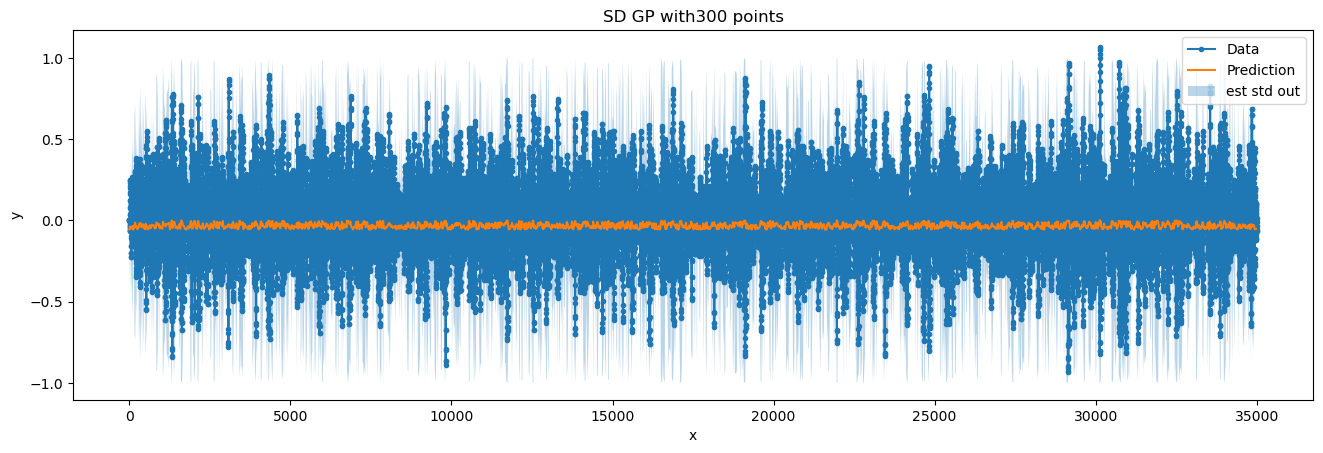

In [56]:
testpoints_sd = (np.mod(range(N),20)==0)
f_sd,cov_sd = post(x1[include_sd,:],x2[testpoints_sd,:],y1[include_sd],width_sd,kernel,noise=noise_sd)
var_sd = np.diag(cov_sd)

sd_msll = MSLL(y1[testpoints_sd,:],f_sd,noise_sd,var_sd)
f_sd = f_sd[:,0]

sd_rmse = np.mean((y1[testpoints_sd]-f_sd)**2)**0.5

name = "SD GP with" + str(M_sd) + " points"
demonstrate(full_range,y1,f_sd,var_sd,testpoints_sd,name)

In [57]:
# PP GP

width_pp = 0.5
noise_pp = 0.1

pp_start = time.time()
f_pp,cov_pp = post(x1,x2,y1,width_pp,kernel,noise_pp,project=True,included=include_sd)
var_pp = np.diag(cov_pp)[:,None]
pp_end = time.time()
pp_run = pp_end - pp_start + sd_run
pp_msll = MSLL(y1,f_pp,noise_pp,var_pp,project=True,included=include_sd)

f_pp = f_pp[:,0]
var_pp = var_pp[:,0]



KeyboardInterrupt: 

In [ ]:
name = 'Projective GP'
testpoints_pp = np.ones([N],dtype="bool")
demonstrate(full_range,y1,f_pp,var_pp,testpoints_pp,name)

# Bayseian committee machine

In [56]:
# Setup

width_bcm = 0.5
noise_bcm = 0.1

p_bcm = 70 #no of partitions

M_bcm = 500 #partition block size

t_bcm = 35000 #test block size
s_bcm = M_bcm #SD approximation block size
testpoints_bcm = (np.mod(range(N),1)==0)

x22 = x2[testpoints_bcm]

bcm_start = time.time()

f_bcm = np.array(np.zeros([t_bcm, p_bcm]))
f_bcm_run = np.array(np.zeros(t_bcm))
var_bcm = f_bcm
include_bcm = np.array(np.zeros([N, p_bcm]),dtype="bool")

#inv_cov_bcm = np.array(np.zeros([t_bcm, t_bcm, p_bcm]))
#inv_cov_bcm_run = np.array(np.zeros([t_bcm, t_bcm]))

inv_cov_bcm = np.array(np.zeros([t_bcm, p_bcm]))
inv_cov_bcm_run = np.array(np.zeros([t_bcm]))


#[p*M_bcm:((p+1)*M_bcm),:]

#Try to combine SD with BCM?

#hyperinclude_bcm = np.ones([N,p_bcm],dtype='bool')

# + *ExpSineSquared(length_scale=0.5,periodicity=0.5)

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-9, 1e1))  + RBF(length_scale=0.5) + ConstantKernel() #DotProduct()   #a=)
reg_bcm = np.zeros([p_bcm],dtype='object')
noise_bcm = np.zeros([p_bcm],dtype='float')

In [57]:
# Training

for p in tqdm(range(p_bcm)):
    x11 = x1[np.mod(np.array(range(N))+p,p_bcm)==0]
    y11 = y1[np.mod(np.array(range(N))+p,p_bcm)==0]
    reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=10) #a=)
    reg_bcm[p].fit(x11,y11) #a)
    #f_bcm[:,p], inv_cov_bcm[:,:,p] = reg_bcm[p].predict(x22,return_cov=True)
    f_bcm[:,p], inv_cov_bcm[:,p] = reg_bcm[p].predict(x22,return_std=True)
    noise_bcm[p] = np.exp(reg_bcm[p].kernel_.k2.theta)[0]**0.5 #extract the noise

    
    #f_temp,cov_bcm[:,:,p] = post(x11,x22,y11,width_bcm,kernel,noise_bcm)
    #f_temp,hyperinclude_bcm[:,p],cov_bcm[:,:,p] = sd_algo(x1,x2,y1,M_bcm,width_bcm,kernel,noise_bcm,testiness=1,quiet=True)
    #f_bcm[:,p] = f_temp[:,0]

    #inv_cov_bcm[:,:,p] = np.linalg.inv(inv_cov_bcm[:,:,p])
    #inv_cov_bcm_run = inv_cov_bcm_run + inv_cov_bcm[:,:,p]
    #f_bcm_run = f_bcm_run + inv_cov_bcm[:,:,p]@f_bcm[:,p]

    inv_cov_bcm[:,p] = inv_cov_bcm[:,p]**-1
    inv_cov_bcm_run = inv_cov_bcm_run + inv_cov_bcm[:,p]
    f_bcm_run = f_bcm_run + inv_cov_bcm[:,p]*f_bcm[:,p]
    

#K22 = slice(x22,x22,rbf,width_bcm)
#cov_bcm = np.linalg.inv( -(p_bcm-1)*np.linalg.inv(K22)  +   inv_cov_bcm_run)
#var_bcm = np.diag(cov_bcm)
#f_bcm = cov_bcm@f_bcm_run

K22 = slice(x22,x22,rbf,width_bcm,axis=0)
cov_bcm = ( -(p_bcm-1)*(K22**-1)  +   inv_cov_bcm_run)**-1
var_bcm = cov_bcm
f_bcm = cov_bcm*f_bcm_run

bcm_end = time.time()
bcm_run = bcm_end - bcm_start

  0%|          | 0/70 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  1%|▏         | 1/70 [00:02<02:57,  2.58s/it]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 1e-09. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e

WhiteKernel(noise_level=1.07e-05) + RBF(length_scale=9.3) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=10.6) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=9.02) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.74) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.68) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.57) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.56) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.71) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.65) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.56) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.67) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.97) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.58) + 0.00316**2
WhiteKernel(noise_level=1e-09) + RBF(length_scale=8.62) + 0.00316**2
WhiteKernel(noise_level=1e-09) +

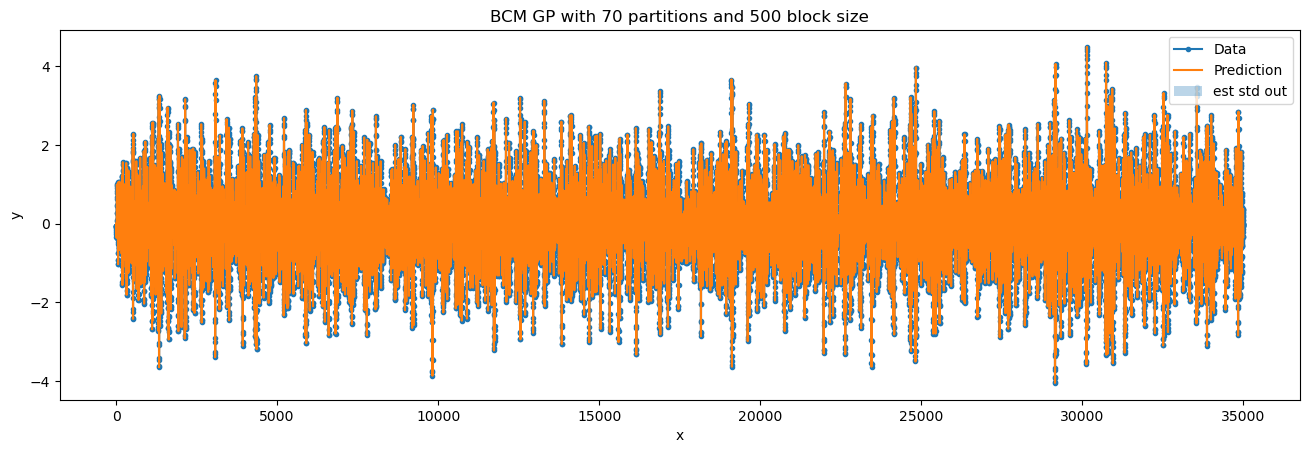

In [58]:
bcm_msll = MSLL(y1[testpoints_bcm],f_bcm,np.mean(noise_bcm),var_bcm)
#bcm_rmse = np.mean((y1[testpoints_bcm]-f_bcm)**2)**0.5
bcm_rmse = sklearn.metrics.root_mean_squared_error(y1[testpoints_bcm], f_bcm)

for p in range(p_bcm): print(reg_bcm[p].kernel_)
print(bcm_rmse*norm_y)
print(norm_y)


name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(s_bcm) + " block size"
demonstrate(full_range,y1,f_bcm,var_bcm,testpoints_bcm,name)


In [70]:
#print("Classic algorithm runtime = ", classic_run)
#print("Classic algorithm utility = ", -classic_msll, "\n")

print("SD algorithm runtime = ", sd_run)
print("SD algorithm utility = ", -sd_msll)
print("SD algorithm RMSE = ", sd_rmse, "\n")

#
#print("PP algorithm runtime = ", pp_run)
#print("PP algorithm utility = ", -pp_msll, "\n")

print("BCM algorithm runtime = ", bcm_run)
print("BCM algorithm utility = ", -bcm_msll)
print("BCM algorithm RMSE = ", bcm_rmse)

print(norm_y)

SD algorithm runtime =  134.86613583564758
SD algorithm utility =  -0.5254826343648543
SD algorithm RMSE =  0.242776680210773 

BCM algorithm runtime =  628.5384333133698
BCM algorithm utility =  1.3310300079092419
BCM algorithm RMSE =  0.3317862238724803
2.0404644285065707
